<a href="https://colab.research.google.com/github/ChungViTin/TH_DeepLearning/blob/main/TH_DeepLearning_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
path = '/content/drive/MyDrive/TH_DeepLearning'
print(os.listdir(path))

['Thực hành học sâu (1TC)', 'processed_dulieuxettuyendaihoc.csv', 'processed_heart_disease.csv', 'dulieuxettuyendaihoc.csv', 'heart_disease_dataset.csv', 'generated_500_homes.csv']


# Mô hình dự đoán bệnh tim

### Tải và làm sạch dữ liệu
Tải tập dữ liệu và thực hiện làm sạch ban đầu (xử lý các giá trị thiếu và trùng lặp) trước khi chuyển sang chia tập dữ liệu thành Huấn luyện/Xác thực/Kiểm thử.

In [ ]:
import pandas as pd
import numpy as np

# URL of the dataset
url = 'https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/heart_disease_dataset.csv'

# Tải data
df = pd.read_csv(url)

# Hiển thị thông tin cơ bản và một vài dòng đầu tiên
print("Dataset Info:")
display(df.info())
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB


None

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


In [ ]:
# 1. Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0] if missing_values.any() else "No missing values found.")

# 2. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# 3. Basic statistics for numerical columns
print("\nNumerical Statistics:")
display(df.describe())

Missing values in each column:
age          8
sex          8
cp          11
trestbps     8
chol        10
fbs          8
restecg      8
thalach     12
exang        8
oldpeak      8
slope        8
ca          12
thal         8
state       10
dtype: int64

Number of duplicate rows: 7
Duplicates removed.

Numerical Statistics:


,age,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,state
count,295.000000,295.000000,293.000000,295.000000,291.000000,295.000000,295.000000,295.000000,291.000000,295.000000,293.000000
mean,54.362712,131.389831,247.225256,1.003390,150.054983,0.318644,1.038644,1.589831,0.656357,4.671186,0.928328
std,9.040007,17.271361,51.819006,0.994879,22.684882,0.466742,1.170266,0.615474,0.931509,1.968377,1.229621
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,0.000000,136.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,130.000000,242.000000,1.000000,153.000000,0.000000,0.700000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,140.000000,276.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### Dữ liệu làm sạch cuối cùng
Chúng ta sẽ loại bỏ các hàng có giá trị bị thiếu để đảm bảo tính toàn vẹn của dữ liệu trước khi chia tách.

In [ ]:
# Drop rows with any missing values
df_cleaned = df.dropna()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

# Quick look at the target variable distribution
print("\nTarget (state) distribution:")
print(df_cleaned['state'].value_counts())

# Set the cleaned df as the main df for next steps
df = df_cleaned

Original dataset size: 296
Cleaned dataset size: 284

Target (state) distribution:
state
0.0    155
1.0     52
2.0     34
3.0     30
4.0     13
Name: count, dtype: int64


### Trực quan hóa dữ liệu trước khi xử lý
Chúng ta sẽ xem xét phân phối của các biến số và sự cân bằng của tập dữ liệu.

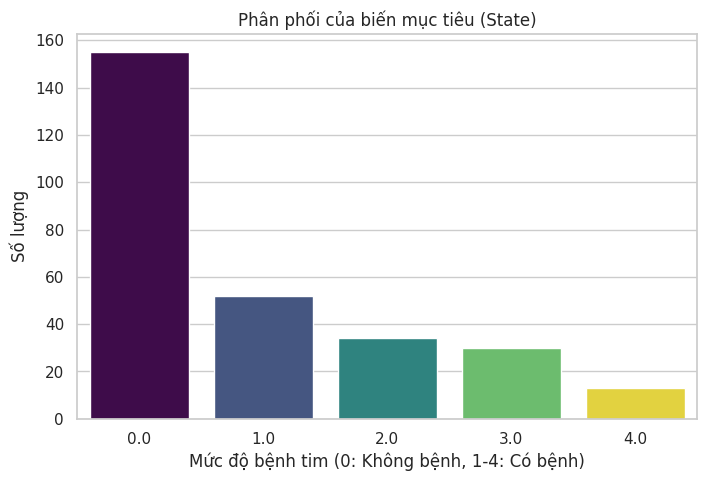

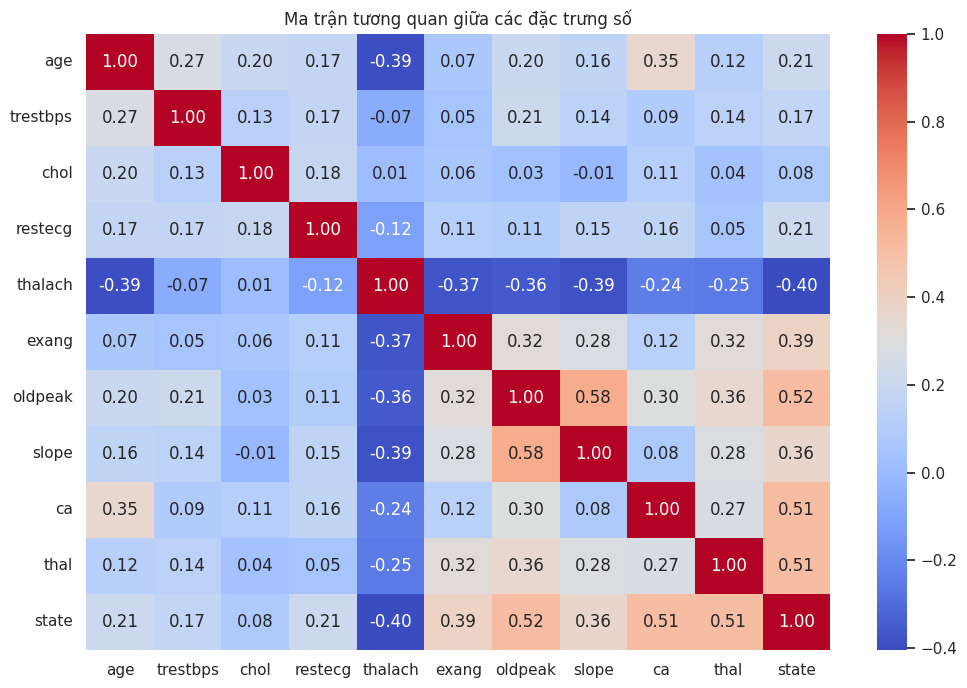

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")

# 1. Trực quan hóa biến mục tiêu 'state'
plt.figure(figsize=(8, 5))
sns.countplot(x='state', data=df, palette='viridis', hue='state', legend=False)
plt.title('Phân phối của biến mục tiêu (State)')
plt.xlabel('Mức độ bệnh tim (0: Không bệnh, 1-4: Có bệnh)')
plt.ylabel('Số lượng')
plt.show()

# 2. Biểu đồ Heatmap tương quan giữa các biến số
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các đặc trưng số')
plt.show()

### Bước 1: Chia dữ liệu (Split Data)
Chúng ta sẽ chia dữ liệu thành 3 phần: **Train**, **Validation**, và **Test**.
- **X**: Các đặc trưng (features).
- **y**: Nhãn mục tiêu (biến 'state').

In [ ]:
from sklearn.model_selection import train_test_split

# Xác định Features (X) và Target (y)
X = df.drop('state', axis=1)
y = df['state']

# Chia dữ liệu: 70% Train, 30% còn lại (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Chia 30% còn lại thành 50% Val và 50% Test (tương đương mỗi tập chiếm 15% tổng dữ liệu)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Validation: {X_val.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (198, 13)
Kích thước tập Validation: (43, 13)
Kích thước tập Test: (43, 13)


### Bước 2 & 3: Khớp bộ tiền xử lý và Biến đổi dữ liệu (Fit và Transform)
Chúng ta sẽ sử dụng `ColumnTransformer` để áp dụng các kỹ thuật khác nhau cho từng loại cột. Sau đó, chúng ta `.fit()` trên tập Train và `.transform()` cho cả 3 tập.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Xác định các loại cột
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Khởi tạo ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# BƯỚC 2: Chỉ fit trên tập TRAIN
preprocessor.fit(X_train)

# BƯỚC 3: Transform cả 3 tập
X_train_preprocessed = preprocessor.transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

print("Tiền xử lý hoàn tất.")
print(f"Hình dạng tập Train sau xử lý: {X_train_preprocessed.shape}")

Tiền xử lý hoàn tất.
Hình dạng tập Train sau xử lý: (198, 18)


### Trực quan hóa Bước 2 và 3: Hiệu quả của Tiền xử lý
Chúng ta sẽ so sánh phân phối của dữ liệu trước và sau khi dùng `MinMaxScaler` để đảm bảo dữ liệu đã được đưa về khoảng [0, 1].

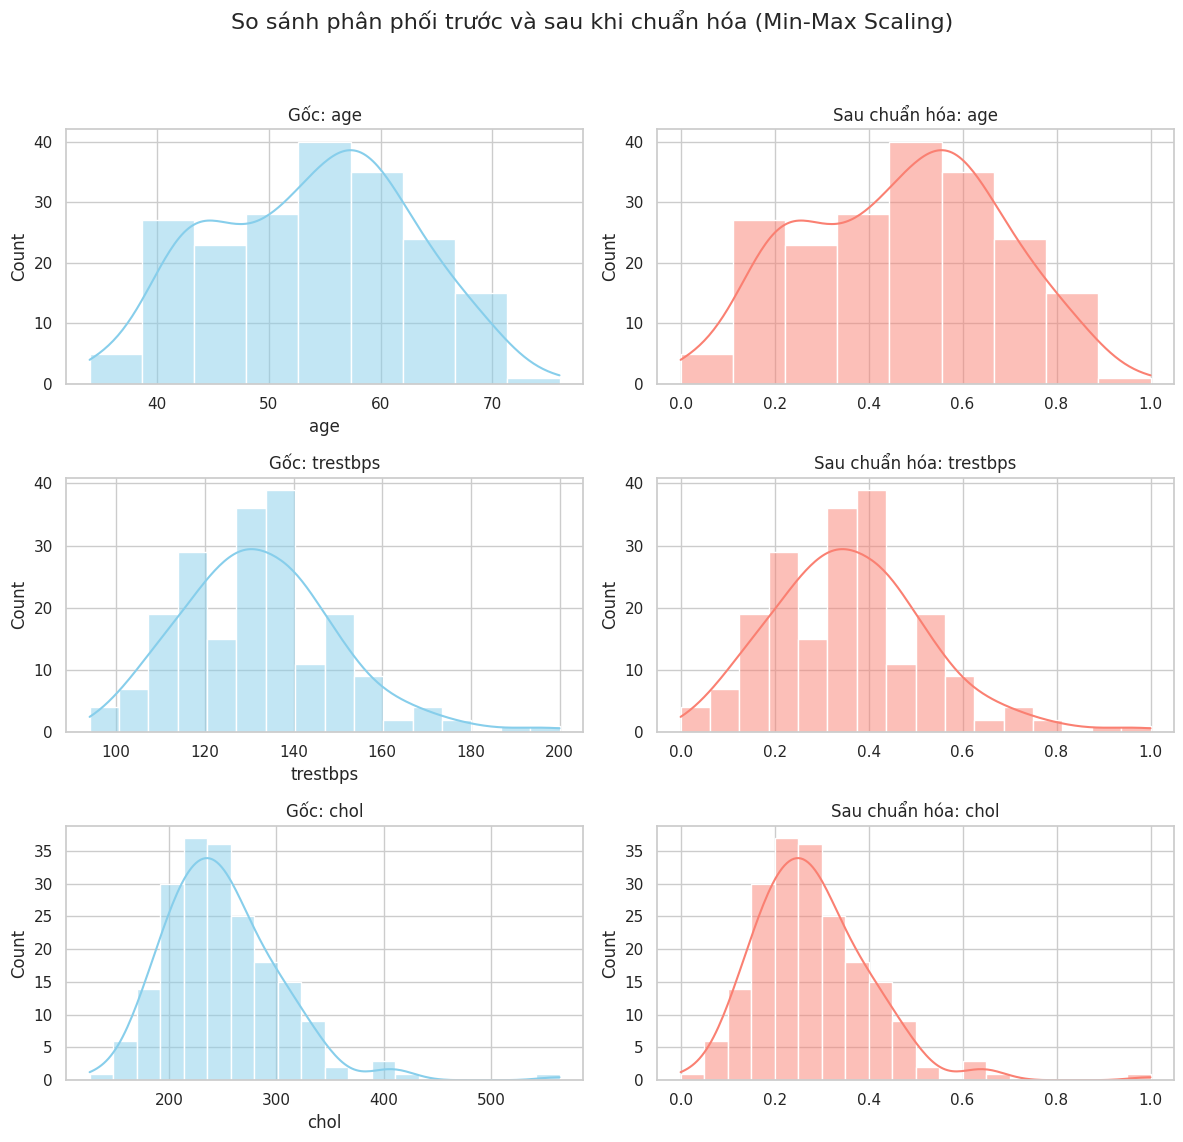

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn một vài cột số để minh họa
cols_to_viz = numerical_cols[:3] # Lấy 3 cột đầu tiên: age, trestbps, chol

fig, axes = plt.subplots(len(cols_to_viz), 2, figsize=(12, 12))
fig.suptitle('So sánh phân phối trước và sau khi chuẩn hóa (Min-Max Scaling)', fontsize=16)

for i, col in enumerate(cols_to_viz):
    # Trước khi xử lý
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Gốc: {col}')

    # Sau khi xử lý (lấy index từ transformer)
    # Lưu ý: Cột số nằm ở đầu mảng sau khi qua ColumnTransformer
    sns.histplot(X_train_preprocessed[:, i], kde=True, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Sau chuẩn hóa: {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Bước 4 và 5: Huấn luyện và Xác thực (Train & Validate)
Chúng ta sẽ sử dụng mô hình Random Forest Classifier để phân loại tình trạng bệnh tim.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Bước 4: Huấn luyện mô hình trên tập Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_preprocessed, y_train)

# Bước 5: Dự đoán và Xác thực trên tập Validation
y_val_pred = model.predict(X_val_preprocessed)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Độ chính xác trên tập Validation: {val_accuracy:.2f}")
print("\nBáo cáo chi tiết trên tập Validation:")
print(classification_report(y_val, y_val_pred))

Độ chính xác trên tập Validation: 0.49

Báo cáo chi tiết trên tập Validation:
              precision    recall  f1-score   support

         0.0       0.69      0.87      0.77        23
         1.0       0.00      0.00      0.00         8
         2.0       0.33      0.20      0.25         5
         3.0       0.00      0.00      0.00         5
         4.0       0.00      0.00      0.00         2

    accuracy                           0.49        43
   macro avg       0.20      0.21      0.20        43
weighted avg       0.41      0.49      0.44        43



### Bước 6: Kiểm tra cuối cùng (Test Once)
Sử dụng tập Test (đã được transform ở Bước 3) để báo cáo kết quả đánh giá cuối cùng.

In [ ]:
# Bước 6: Dự đoán trên tập Test duy nhất một lần
y_test_pred = model.predict(X_test_preprocessed)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"--- KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ---")
print(f"Độ chính xác (Accuracy): {test_accuracy:.2f}")
print("\nBáo cáo phân loại chi tiết:")
print(classification_report(y_test, y_test_pred))

--- KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ---
Độ chính xác (Accuracy): 0.67

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

         0.0       0.71      1.00      0.83        24
         1.0       0.75      0.38      0.50         8
         2.0       0.67      0.40      0.50         5
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         2

    accuracy                           0.67        43
   macro avg       0.42      0.35      0.37        43
weighted avg       0.61      0.67      0.61        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Trực quan hóa kết quả mô hình
Sử dụng Ma trận nhầm lẫn (Confusion Matrix) để xem mô hình dự đoán đúng/sai ở những lớp nào trên tập Test.

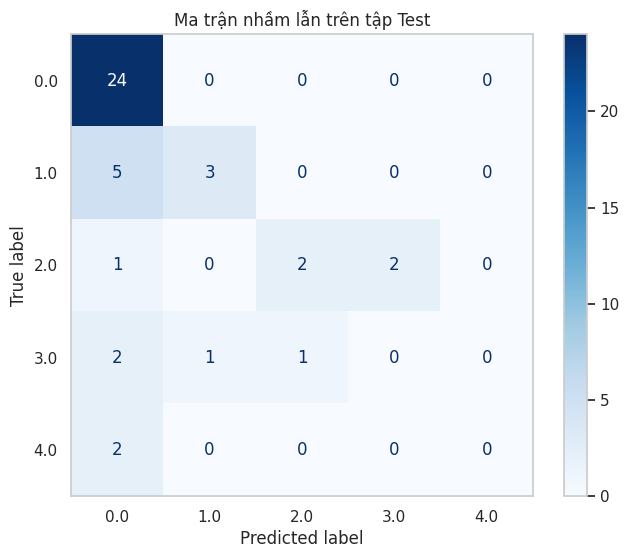

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_test_pred)

# Hiển thị ma trận nhầm lẫn
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.grid(False)
plt.show()